## Tweet Emotion Recognition: Natural Language Processing with TensorFlow

---

Dataset: [Tweet Emotion Dataset](https://github.com/dair-ai/emotion_dataset)

---



## Task 1: Setup and Imports

1. Installing Hugging Face's nlp package
2. Importing libraries

In [1]:
!pip install nlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.9 MB/s eta 0:00:00


In [2]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random


def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()


print('Using TensorFlow version', tf.__version__)

Using TensorFlow version 2.20.0


## Task 2: Importing Data

1. Importing the Tweet Emotion dataset
2. Creating train, validation and test sets
3. Extracting tweets and labels from the examples

In [4]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")
print(dataset)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
train=dataset['train']
val=dataset['validation']
test=dataset['test']

In [7]:
def get_tweet(data):
  tweets= [x['text'] for x in data]
  labels= [x['label'] for x in data]
  return tweets,labels

In [8]:
tweets,labels=get_tweet(train)

In [9]:
tweets[0],labels[0]

('i didnt feel humiliated', 0)

## Task 3: Tokenizer

1. Tokenizing the tweets

In [10]:
#Convert words to numbers

from tensorflow.keras.preprocessing.text import Tokenizer

In [11]:
tokenizer = Tokenizer(num_words=10000,oov_token='<UNK>')
tokenizer.fit_on_texts(tweets)

In [12]:
tokenizer.texts_to_sequences([tweets[0]])

[[2, 139, 3, 679]]

In [13]:
tweets[0]

'i didnt feel humiliated'

## Task 4: Padding and Truncating Sequences

1. Checking length of the tweets
2. Creating padded sequences

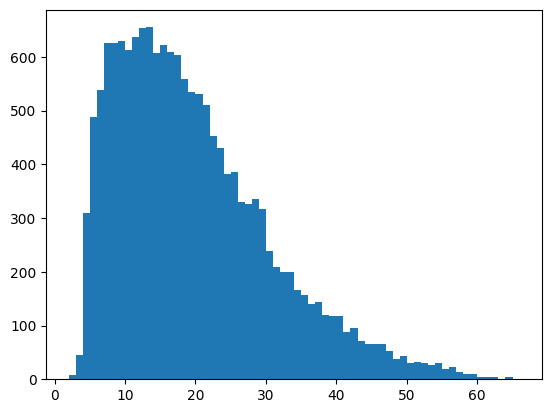

In [14]:
lengths= [len(t.split(' ')) for t in tweets]
plt.hist(lengths,bins=len(set(lengths)))
plt.show()

In [15]:
maxlen=50

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [16]:
def get_sequences(tokenizer,tweets):
  sequences=tokenizer.texts_to_sequences(tweets)
  padded = pad_sequences(sequences,maxlen=maxlen,truncating='post',padding='post')
  return padded

In [17]:
padded_train_seq = get_sequences(tokenizer,tweets)

In [18]:
padded_train_seq[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Task 5: Preparing the Labels

1. Creating classes to index and index to classes dictionaries
2. Converting text labels to numeric labels

In [19]:
classes=set(labels)
print(classes)

{0, 1, 2, 3, 4, 5}


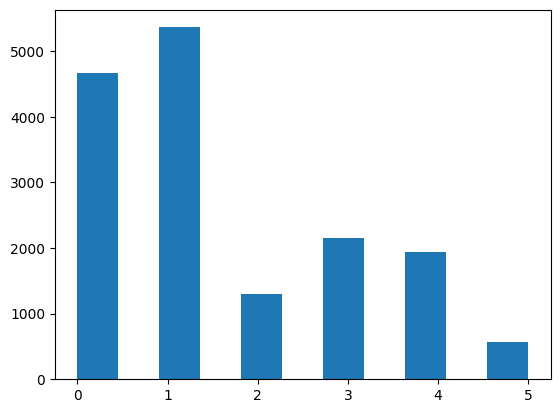

In [20]:
plt.hist(labels,bins=11)
plt.show()

In [21]:
#in this case labels already in numeric form
# Labels:
"""
classes = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

"""
#if not then convert using this code
classes = ["sadness", "joy", "love", "anger", "fear", "surprise"]
classes_to_index= dict((c,i) for i,c in enumerate(classes))
index_to_class=dict((v,k) for k,v in classes_to_index.items())

In [22]:
classes_to_index

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

In [23]:
index_to_class

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

In [24]:
names_to_ids = lambda labels: np.array([classes_to_index.get(x) for x in classes])

In [25]:
train_labels = names_to_ids(labels)
print(train_labels[0])

0


## Task 6: Creating the Model

1. Creating the model
2. Compiling the model

In [26]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_shape=(maxlen,)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 16)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 40)         │         5,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 40)             │         9,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,926 (687.21 KB)

 Trainable params: 175,926 (687.21 KB)

 Non-trainable params: 0 (0.00 B)

## Task 7: Training the Model

1. Preparing a validation set
2. Training the model

In [28]:
val_tweets,val_labels=get_tweet(val)
val_seq = get_sequences(tokenizer,val_tweets)

In [29]:
print(val_tweets[0])
print(val_labels[0])

im feeling quite sad and sorry for myself but ill snap out of it soon
0


In [31]:
X_train = tf.convert_to_tensor(padded_train_seq, dtype=tf.int32)
y_train = tf.convert_to_tensor(labels, dtype=tf.int32)

X_val = tf.convert_to_tensor(val_seq, dtype=tf.int32)
y_val = tf.convert_to_tensor(val_labels, dtype=tf.int32)

In [32]:
h = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=2
        )
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.4681 - loss: 1.3816 - val_accuracy: 0.6880 - val_loss: 0.9276
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7692 - loss: 0.6597 - val_accuracy: 0.7820 - val_loss: 0.6261
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8604 - loss: 0.4088 - val_accuracy: 0.8110 - val_loss: 0.5623
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9121 - loss: 0.2807 - val_accuracy: 0.8500 - val_loss: 0.4838
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9366 - loss: 0.2123 - val_accuracy: 0.8415 - val_loss: 0.5184
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9476 - loss: 0.1744 - val_accuracy: 0.8715 - val_loss: 0.4703
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9594 - loss: 0.1383 - val_accuracy: 0.8805 - val_loss: 0.4171
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9653 - loss: 0.1148 - val_acc

Stopped after 10 epochs because of no improvement further.


## Task 8: Evaluating the Model

1. Visualizing training history
2. Prepraring a test set
3. A look at individual predictions on the test set
4. A look at all predictions on the test set

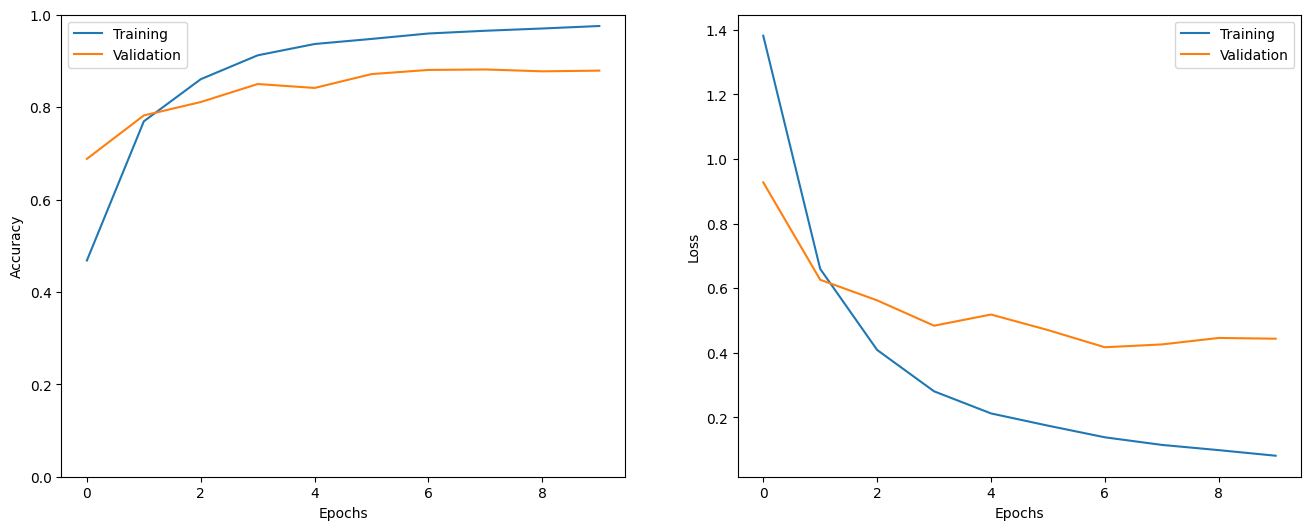

In [33]:
show_history(h)

In [34]:
test_tweets,test_labels=get_tweet(test)
test_seq = get_sequences(tokenizer,test_tweets)

In [35]:
test_seq = tf.convert_to_tensor(test_seq, dtype=tf.int32)
test_labels = tf.convert_to_tensor(test_labels, dtype=tf.int32)

model.evaluate(test_seq, test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8880 - loss: 0.4044


[0.4044075906276703, 0.8880000114440918]

In [43]:
i=random.randint(0,len(test_labels)-1)
print('Sentence:',test_tweets[i])
print('Emotion:',test_labels[i])
p=model.predict(np.expand_dims(test_seq[i],axis=0))[0]
pred_class = index_to_class[np.argmax(p).astype('uint8')]

print("Predicted Emotion:",pred_class)

Sentence: i have finally cast my studio show and it feels fab
Emotion: tf.Tensor(1, shape=(), dtype=int32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Emotion: joy


The model Predicted the emotion in sentence above as `joy` and actual is labelled 1(`joy`)

Labels: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5).

In [44]:
probs=model.predict(test_seq)
import numpy as np
preds = np.argmax(probs, axis=1)
preds

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([0, 0, 0, ..., 1, 1, 5])

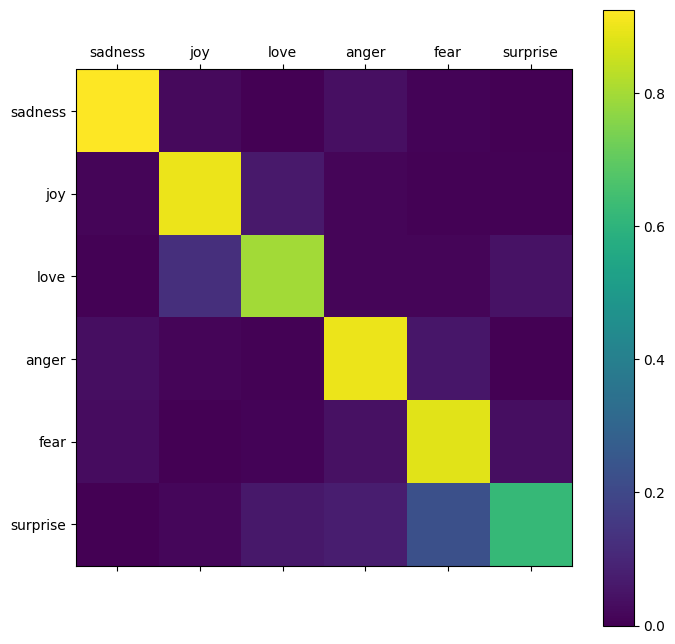

In [45]:
show_confusion_matrix(test_labels,preds,list(classes))